# Analyzing the QE of the WINTER Bench Sensor in the QE Closet

In [ ]:
# QE setup stuff: courtesy of Chris Layden

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import scipy
from integrating_sphere_funcs import sphere_flux_correction
global c
c = 2.998 * 10 ** 10 # speed of light in cm/s
global h
h = 6.626 * 10 ** -27 # Planck's constant in g cm^2/s
this_dir = os.getcwd()

class CalibratedPD(object):
    '''A class to represent a calibrated photodiode.
    
    Attributes:
    ------------
    filename : str
        The complete path to the FITS or csv file containing the calibrated
        photodiode response. The data should have three columns:
        wavelength (nm), response (A/W), and uncertainty in response
        (percent).
    response : numpy.ndarray
        The calibrated photodiode response. First column is
        wavelength in nm, second column is response in A/W. Third
        column is uncertainty in response, in percent.
    area : float
        The area of the photodiode active area, in cm^2.
    plot : bool
        If True, a plot of the response will be generated.
    '''
    def __init__(self, filename, area, plot=False):
        if filename.endswith('.fits'):
            self.response = fits.getdata(filename)
        elif filename.endswith('.csv'):
            self.response = np.genfromtxt(filename, delimiter=',')
        self.area = area
        self.plot = plot
        if plot:
            self.plot_response()

    def plot_response(self):
        '''Plot the calibrated photodiode response.'''
        fig, ax = plt.subplots()
        errors = self.response[:,2] * self.response[:,1] / 100
        ax.errorbar(self.response[:,0], self.response[:,1],
                    yerr=errors, fmt='o')
        ax.set_xlabel('Wavelength (nm)')
        ax.set_ylabel('Response (A/W)')
        ax.set_title('Calibrated Photodiode Response')
        plt.show()

    def get_response(self, wavelength):
        '''Returns the calibrated photodiode response at a given wavelength.'''
        response = np.interp(wavelength, self.response[:,0], self.response[:,1])
        return response
    
data_dir = this_dir + '/data/'
thorlabs_filename = 'ThorLabsPD.csv'
thorlabs_pd = CalibratedPD(thorlabs_filename, 1, plot=True)


class QECalc(object):

    def __init__(self, wavelengths, exp_times, pd_dark_vals, pd_gray_vals,
                 img_dark_vals, img_gray_vals, pix_area, gain, pd,
                 pd_pos=np.array([1,1]), sensor_pos=np.array([1,1]), sensor_size=0,
                 int_sphere_port=4):
        '''Initializes the QECalc object with the necessary data to calculate the QE of the camera.

        Parameters:
        ----------
        wavelengths : numpy.ndarray
            The wavelength for each exposure, in nm.
        exp_times : numpy.ndarray
            The exposure time for each wavelength value, in s. For each wavelength value,
            two exposures are taken at the corresponding exposure time: one with the
            shutter closed and one with the shutter open.
        pd_dark_vals : numpy.ndarray
            The average current measured by the calibrated photodiode for each exposure
            with the shutter closed, in A.
        pd_gray_vals : numpy.ndarray
            The average current measured by the calibrated photodiode for each exposure
            with the shutter open, in A.
        img_dark_vals : numpy.ndarray
            The average pixel value for each exposure with the shutter closed.
        img_gray_vals : numpy.ndarray
            The average pixel value for each exposure with the shutter open.
        pix_area : float
            The area of each pixel in the camera, in cm^2.
        gain : float
            The gain of the camera, in ADU/e-.
        pd: CalibratedPD object
            The calibrated photodiode object used to calculate photon flux.
        pd_pos : numpy.ndarray (optional, default=[1,1])
            The position of the photodiode relative to the integrating sphere port.
            First entry is r, second entry is d. Units must be consistent with
            sensor_pos, sensor_size, and int_sphere_port.
        sensor_pos : numpy.ndarray (optional, default=[1,1])
            The position of the camera sensor relative to the integrating sphere port.
            First entry is r, second entry is d.
        sensor_size : float (optional, default=0)
            The width of the camera sensor. Assumes sensor is square.
        int_sphere_port : int (optional, default=4)
            The diameter of the integrating sphere port.
        '''
        self.wavelengths = wavelengths.astype(np.float64)
        self.exp_times = exp_times.astype(np.float64)
        self.pd_dark_vals = pd_dark_vals.astype(np.float64)
        self.pd_gray_vals = pd_gray_vals.astype(np.float64)
        self.img_dark_vals = img_dark_vals.astype(np.float64)
        self.img_gray_vals = img_gray_vals.astype(np.float64)
        self.pix_area = pix_area
        self.gain = gain
        self.pd = pd
        self.pd_pos = pd_pos
        self.sensor_pos = sensor_pos
        self.sensor_size = sensor_size
        self.int_sphere_port = int_sphere_port
        self.flux_corr = self.get_flux_correction()
        self.qe_vals = self.get_qe_vals()
        # self.depl_depth = self.get_depl_depth()

    def add_points(self, wavelengths, exp_times, pd_dark_vals, pd_gray_vals,
                    img_dark_vals, img_gray_vals):
        '''Adds additional data points to the QECalc object.'''
        self.wavelengths = np.append(self.wavelengths, wavelengths)
        self.exp_times = np.append(self.exp_times, exp_times)
        self.pd_dark_vals = np.append(self.pd_dark_vals, pd_dark_vals)
        self.pd_gray_vals = np.append(self.pd_gray_vals, pd_gray_vals)
        self.img_dark_vals = np.append(self.img_dark_vals, img_dark_vals)
        self.img_gray_vals = np.append(self.img_gray_vals, img_gray_vals)
        self.qe_vals = self.get_qe_vals()
        # self.depl_depth = self.get_depl_depth()

    def add_qe_points(self, wavelengths, qe_vals):
        '''Adds additional QE data points to the QECalc object.'''
        self.wavelengths = np.append(self.wavelengths, wavelengths)
        self.qe_vals = np.append(self.qe_vals, qe_vals)
        self.exp_times = np.append(self.exp_times, np.zeros_like(wavelengths) * np.NaN)
        self.pd_dark_vals = np.append(self.pd_dark_vals, np.zeros_like(wavelengths) * np.NaN)
        self.pd_gray_vals = np.append(self.pd_gray_vals, np.zeros_like(wavelengths) * np.NaN)
        self.img_dark_vals = np.append(self.img_dark_vals, np.zeros_like(wavelengths) * np.NaN)
        self.img_gray_vals = np.append(self.img_gray_vals, np.zeros_like(wavelengths) * np.NaN)
        # self.depl_depth = self.get_depl_depth()

    def get_flux_correction(self):
        '''Find correction factor for PD and sensor being at different positions relative to sphere.'''
        flux_corr = sphere_flux_correction(self.int_sphere_port, self.pd_pos[0], self.pd_pos[1],
                                           self.sensor_pos[0], self.sensor_pos[1], self.sensor_size)
        return flux_corr

    def get_qe_vals(self):
        '''Calculates the quantum efficiencies of the camera at each wavelength.'''
        qe_vals = np.zeros_like(self.pd_dark_vals)
        for i, wavelength in enumerate(self.wavelengths):
            pd_response = self.pd.get_response(wavelength)
            # Get the photon energy rate, in ergs/s
            phot_energy_rate = (self.pd_gray_vals[i] - self.pd_dark_vals[i]) / pd_response * 10 ** 7
            phot_energy = h * c / (wavelength * 10 ** -7)
            # Get the absolute photon flux, in phot/s/cm^2
            abs_phot_flux = phot_energy_rate / phot_energy / self.pd.area * self.flux_corr
            # Get the number of photons collected at the sensor per pixel per second
            img_phot_pix = (self.img_gray_vals[i] - self.img_dark_vals[i]) / self.gain / self.exp_times[i]
            qe_vals[i] = img_phot_pix / self.pix_area / abs_phot_flux
        return qe_vals
    
    def interp_qe(self, wavelength):
        '''Interpolates the quantum efficiency of the camera at a given wavelength.'''
        qe = np.interp(wavelength, self.wavelengths, self.qe_vals)
        return qe
    
    def get_depl_depth(self):
        '''Estimates the sensor depletion depth by fitting to silicon absorption.'''
        dir = os.path.abspath('')
        silicon_abs = np.genfromtxt(dir + '/data/silicon_absorption.csv', delimiter=',')
        def theoretical_qe(wavelength, depletion_depth, max_qe=1):
            '''Returns the theoretical quantum efficiency of silicon at a given wavelength'''
            abs_length = np.interp(wavelength, silicon_abs[:, 0], silicon_abs[:, 1])
            return (1 - np.exp(-depletion_depth / abs_length)) * max_qe
        fit_cut_on_wavelength = 600
        wavelength_arr = self.wavelengths[self.wavelengths > fit_cut_on_wavelength]
        qe_arr = self.qe_vals[self.wavelengths > fit_cut_on_wavelength]
        if len(wavelength_arr) < 5:
            raise ValueError('Not enough data points >600 nm to fit to silicon absorption.')
        popt, pcov = scipy.optimize.curve_fit(theoretical_qe, wavelength_arr, qe_arr, p0=[10, 1])
        return popt
    
    def plot_qe(self):
        '''Plots the quantum efficiency of the camera as a function of wavelength.'''
        #plt.scatter(self.wavelengths, self.qe_vals)
        plt.plot(self.wavelengths, self.qe_vals, 'o-')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Quantum Efficiency')
        #plt.ylim(0, 1)
        plt.show()



In [ ]:
from pathlib import Path
from typing import Union, List, Dict, Optional

import numpy as np
import pandas as pd
from astropy.io import fits


def _parse_p_float(s: str) -> float:
    """
    Convert strings like:
      - '0p002'  ->  0.002
      - '3.5'    ->  3.5
      - 'm10'    -> -10.0
      - 'm0p5'   -> -0.5

    Convention:
      - 'p' is used instead of '.' in some fields
      - leading 'm' means a negative value
    """
    s = s.strip()

    # Handle "m" = minus convention, e.g. 'm10' -> '-10'
    if s.startswith("m"):
        s = "-" + s[1:]

    # Handle 'p' as decimal point, e.g. '0p429' -> '0.429'
    s = s.replace("p", ".")

    return float(s)


def _parse_filename_metadata(stem: str) -> Optional[Dict]:
    """
    Parse filenames like:
    bench_20251124_texp_3_dark_0p002_nA_0C_400nm_20251124-213632-944
    bench_20251125_texp_3.5_light_0p429_nA_m10C_1064nm_20251125-164906-287

    Returns dict of parsed fields or None if not matched.
    """
    parts = stem.split("_")
    if len(parts) < 10:
        return None
    if parts[2] != "texp":
        return None
    if parts[6] != "nA":
        return None

    sensor_name = parts[0]
    date_str = parts[1]
    exposure_raw = parts[3]
    frame_type = parts[4].lower()
    pd_current_raw = parts[5]
    temp_raw = parts[7]
    filt_raw = parts[8]
    acq_time_utc = parts[9]

    exposure_time = _parse_p_float(exposure_raw)
    pd_current_nA = _parse_p_float(pd_current_raw)
    temperature_C = _parse_p_float(temp_raw.rstrip("Cc"))

    if filt_raw.lower().endswith("nm"):
        filter_center_nm = _parse_p_float(filt_raw[:-2])
    else:
        filter_center_nm = None

    return {
        "sensor_name": sensor_name,
        "obs_date": date_str,
        "frame_type": frame_type,
        "exposure_time": exposure_time,
        "pd_current": pd_current_nA,
        "temperature": temperature_C,
        "filter_center": filter_center_nm,
        "acq_time_utc": acq_time_utc,
    }


def _make_datasec_mask_and_apply(data: np.ndarray, header, fill_value: float):
    """
    Build a boolean mask from DATASEC and apply it to data by filling
    out-of-region pixels with `fill_value`.

    Returns
    -------
    mask : np.ndarray (bool)
    datasec_str : str or None
    """
    datasec_str = header.get("DATASEC")
    # default: everything valid if no DATASEC
    mask = np.ones_like(data, dtype=bool)

    if datasec_str is None:
        return mask, None

    # Example DATASEC: '[xmin:xmax,ymin:ymax]'
    try:
        datasec = datasec_str.replace("[", "").replace("]", "").split(",")
        datasec_xmin = int(datasec[0].split(":")[0])
        datasec_xmax = int(datasec[0].split(":")[1])
        datasec_ymin = int(datasec[1].split(":")[0])
        datasec_ymax = int(datasec[1].split(":")[1])

        # Start with everything False, then mark DATASEC True
        mask = np.zeros_like(data, dtype=bool)
        mask[datasec_ymin:datasec_ymax, datasec_xmin:datasec_xmax] = True

        # Apply fill value outside DATASEC
        data[~mask] = fill_value

    except Exception as exc:
        # If anything goes wrong, fall back to all True, but keep datasec_str
        print(f"Warning: failed to parse DATASEC '{datasec_str}': {exc}")
        mask = np.ones_like(data, dtype=bool)

    return mask, datasec_str


def crawl_fits_files(
    folder: Union[str, Path],
    fill_value: float = np.nan,
) -> pd.DataFrame:
    """
    Crawl a directory for .fits files, parse filename metadata,
    load FITS image data, and construct a DATASEC-based mask.
    """
    folder = Path(folder)
    rows: List[Dict] = []

    for path in folder.rglob("*.fits"):
        meta = _parse_filename_metadata(path.stem)
        if meta is None:
            continue

        try:
            with fits.open(path) as hdul:
                # Assuming primary HDU holds the science image & header
                data = np.asarray(hdul[0].data, dtype=float)
                header = hdul[0].header

            mask, datasec_str = _make_datasec_mask_and_apply(
                data, header, fill_value=fill_value
            )

        except Exception as exc:
            print(f"Warning: failed reading {path}: {exc}")
            continue

        row = {
            "filename": path.name,
            "filepath": str(path),
            "data": data,
            "mask": mask,
            "datasec": datasec_str,
            **meta,
        }
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)

    preferred_cols = [
        "filename",
        "filepath",
        "frame_type",
        "exposure_time",
        "filter_center",
        "temperature",
        "pd_current",
        "data",
        "mask",
    ]
    other_cols = [c for c in df.columns if c not in preferred_cols]
    df = df[preferred_cols + other_cols]

    return df


In [ ]:
# Import the data
import os
data_dir = os.path.join(os.getenv("HOME"), "data", "winter","qe_measurements", "qe_lab_20251125")
print(f"crawling for data in {data_dir}")

df = crawl_fits_files(data_dir)
print(f"Found {len(df)} FITS files with expected naming pattern.")
display(df)


In [ ]:
def histogram_peak_in_band(
    data: np.ndarray,
    mask: np.ndarray | None = None,
    bins: int = 100,
    freq_thresh: int = 0,
    value_min: float = -np.inf,
    value_max: float = np.inf,
):
    """
    Compute the peak bin center within a value and frequency band.

    Returns
    -------
    peak_value : float
        Bin center with the highest count among selected bins, or np.nan if none.
    hist : np.ndarray
        Histogram counts.
    edges : np.ndarray
        Histogram bin edges.
    bin_centers : np.ndarray
        Centers of the bins.
    selected_bins : np.ndarray (bool)
        True for bins that were considered (within band and above freq_thresh).
    """
    if mask is not None:
        values = data[mask].ravel()
    else:
        values = data.ravel()

    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, None, None, None, None

    hist, edges = np.histogram(values, bins=bins)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    selected_bins = (
        (bin_centers >= value_min) &
        (bin_centers <= value_max) &
        (hist >= freq_thresh)
    )

    if not np.any(selected_bins):
        peak_value = np.nan
    else:
        # argmax only over selected bins
        idx_local = np.argmax(hist[selected_bins])
        idx_global = np.where(selected_bins)[0][idx_local]
        peak_value = float(bin_centers[idx_global])

    return peak_value, hist, edges, bin_centers, selected_bins


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from analysis.utils.utils import plot_image

exptimes = df['exposure_time'].unique()
print(f"Unique exposure times (s): {exptimes}")

filters = df['filter_center'].unique()
print(f"Unique filter centers (nm): {filters}, type(filters)={type(filters)}")

# sort the filters small to big
filters = np.sort(filters)

# filters = np.array([1000])

pd_current_light = np.array([])
pd_current_dark = np.array([])
pd_diff = np.array([])
counts_diff = np.array([])
exptimes = np.array([])

for filt in filters:
    df_filt = df[df['filter_center'] == filt]
    print(f"\nFilter center: {filt} nm, {len(df_filt)} files")

    light_frames = df_filt[df_filt['frame_type'] == 'light']
    dark_frames = df_filt[df_filt['frame_type'] == 'dark']

    light_frame = light_frames.iloc[0]
    dark_frame = dark_frames.iloc[0]

    pd_current_light = np.append(pd_current_light, light_frame['pd_current'])
    pd_current_dark = np.append(pd_current_dark, dark_frame['pd_current'])

    exptimes = np.append(exptimes, light_frame['exposure_time'])

    print(f"\tLIGHT: pd_current = {light_frame['pd_current']} nA")
    print(f"\tDARK:  pd_current = {dark_frame['pd_current']} nA")

    pd_diff = np.append(pd_diff, light_frame['pd_current'] - dark_frame['pd_current'])

    light_data = light_frame['data']
    dark_data = dark_frame['data']
    light_mask = light_frame.get('mask', None)
    dark_mask = dark_frame.get('mask', None)

    diff_data = light_data - dark_data
    if light_mask is not None and dark_mask is not None:
        diff_mask = light_mask & dark_mask
    else:
        diff_mask = None

    nbins = 1000

    # band parameters (tuned separately for each distribution)
    freq_thresh_light = 10000
    band_light_min = 20000
    band_light_max = 45000

    freq_thresh_dark = 10000
    band_dark_min = 1000
    band_dark_max = 15000

    freq_thresh_diff = 15000
    band_diff_min = 10000
    band_diff_max = 40000

    # --- compute PEAKS (not medians) & histogram details ---
    peak_light, hL, eL, cL, selL = histogram_peak_in_band(
        light_data, mask=light_mask, bins=nbins,
        freq_thresh=freq_thresh_light,
        value_min=band_light_min, value_max=band_light_max
    )
    peak_dark, hD, eD, cD, selD = histogram_peak_in_band(
        dark_data, mask=dark_mask, bins=nbins,
        freq_thresh=freq_thresh_dark,
        value_min=band_dark_min, value_max=band_dark_max
    )
    peak_diff, hR, eR, cR, selR = histogram_peak_in_band(
        diff_data, mask=diff_mask, bins=nbins,
        freq_thresh=freq_thresh_diff,
        value_min=band_diff_min, value_max=band_diff_max
    )

    print(f"\tLIGHT hist peak (band): {peak_light}")
    print(f"\tDARK  hist peak (band): {peak_dark}")
    print(f"\tDIFF  hist peak (band): {peak_diff}")

    # --- plots ---
    fig, axes = plt.subplots(2, 3, figsize=(25, 10))
    plot_image(light_data, ax=axes[0, 0], title="LIGHT Frame")
    plot_image(dark_data,  ax=axes[0, 1], title="DARK Frame")
    plot_image(diff_data,  ax=axes[0, 2], title="DIFFERENCE Frame")

    def plot_hist_with_band(
        ax,
        hist, edges, centers, selected,
        peak_val,
        band_min, band_max,
        title,
    ):
        if hist is None:
            ax.set_title(title + "\n(no data)")
            return

        width = edges[1] - edges[0]

        # Full histogram
        ax.bar(centers, hist, width=width, align='center', alpha=0.5, label="all bins")

        # Highlight the bins used for the peak search
        ax.bar(
            centers[selected],
            hist[selected],
            width=width,
            align='center',
            alpha=0.8,
            color='C1',
            label='used for peak'
        )

        # Shade the value band we requested
        ax.axvspan(band_min, band_max, color='C2', alpha=0.1, label='value band')

        # Vertical line at the peak (if we got one)
        if np.isfinite(peak_val):
            ax.axvline(peak_val, color='r', linestyle='--', linewidth=1, label='peak')

        ax.set_title(title)
        ax.set_xlabel("Pixel Value")
        ax.set_ylabel("Frequency")
        ax.legend()

    plot_hist_with_band(
        axes[1, 0], hL, eL, cL, selL,
        peak_light,
        band_light_min, band_light_max,
        f"LIGHT Histogram\npeak_band={peak_light:.1f}"
    )
    plot_hist_with_band(
        axes[1, 1], hD, eD, cD, selD,
        peak_dark,
        band_dark_min, band_dark_max,
        f"DARK Histogram\npeak_band={peak_dark:.1f}"
    )
    plot_hist_with_band(
        axes[1, 2], hR, eR, cR, selR,
        peak_diff,
        band_diff_min, band_diff_max,
        f"DIFF Histogram\npeak_band={peak_diff:.1f}"
    )

    plt.suptitle(f"Filter center: {filt} nm", fontsize=16)
    plt.tight_layout()

    # store the difference "counts" (peak of diff distribution)
    counts_diff = np.append(counts_diff, peak_diff)


In [ ]:
# plot the wavlength dependence of the results
w = 5
fig, axes = plt.subplots(1, 4, figsize=(w*4, w))
axes[0].plot(filters, pd_diff, 'o', label='PD Current Difference (nA)')
axes[0].set_xlabel("Filter Center (nm)")
axes[0].set_ylabel("PD Current Difference (nA)")
axes[0].legend()

axes[1].plot(filters, counts_diff, 's', label='CCD Counts Difference (peak)')
axes[1].set_xlabel("Filter Center (nm)")
axes[1].set_ylabel("CCD Counts Difference (peak)")
axes[1].legend()

axes[2].plot(filters, thorlabs_pd.get_response(filters), '^', label='PD Response (A/W)')
axes[2].set_xlabel("Filter Center (nm)")
axes[2].set_ylabel("PD Response (A/W)")
axes[2].legend()

axes[3].plot(filters, pd_diff*thorlabs_pd.get_response(filters), 'd', label='Optical Power (nW)')
axes[3].set_xlabel("Filter Center (nm)")
axes[3].set_ylabel("Optical Power (nW)")
axes[3].legend()

plt.suptitle("Signal vs Wavlength", fontsize=16)
plt.tight_layout()

[0.89241085 0.24628949 0.31073233 0.21486957 0.28163929 0.23631194
 0.06829893 0.04941659 0.26866491]
wavelengths: [ 400.  500.  600.  640.  700.  800.  900. 1000. 1064.]
qe_vals: [0.89241085 0.24628949 0.31073233 0.21486957 0.28163929 0.23631194
 0.06829893 0.04941659 0.26866491]


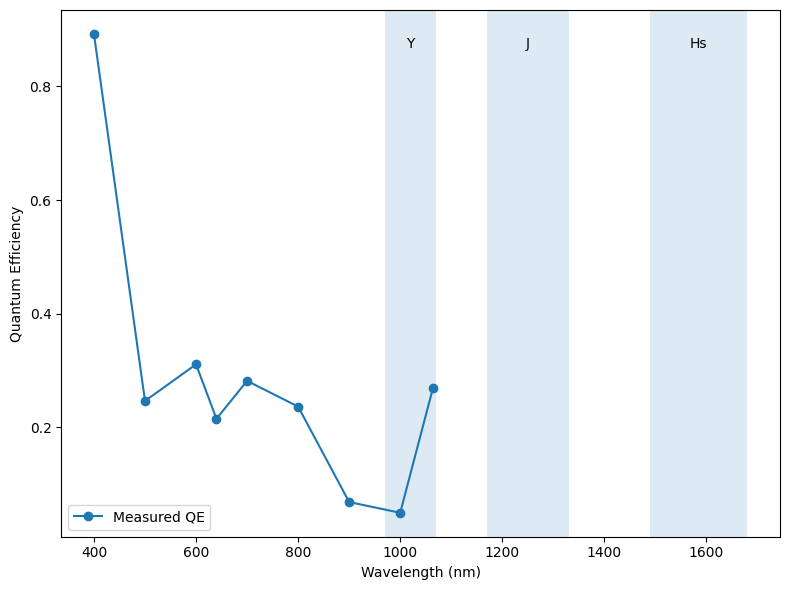

In [62]:
# QE calculation!

wavelengths = filters
exp_times = exptimes
pd_darks = np.zeros_like(wavelengths)  # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.
pd_readings = pd_current_light * 1e-9  # convert nA to A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = counts_diff  # CCD counts (from histogram peak of diff

meas_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 2.5, thorlabs_pd)
print(meas_qe.qe_vals)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_qe.wavelengths, meas_qe.qe_vals, 'o-', label='Measured QE')


print(f"wavelengths: {meas_qe.wavelengths}")
print(f"qe_vals: {meas_qe.qe_vals}")

# overplot the passbands: 
# Define bands: (wl_min, wl_max)
bands = {
    "Y":  (970, 1070),
    "J":  (1170, 1330),
    "Hs": (1490, 1680),
}

# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )

ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)
ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
plt.legend()
plt.tight_layout()
plt.show()




Single-point QE calculation at 1050 nm
[0.04561176]
wavelengths: [1050.]
qe_vals: [0.04561176]


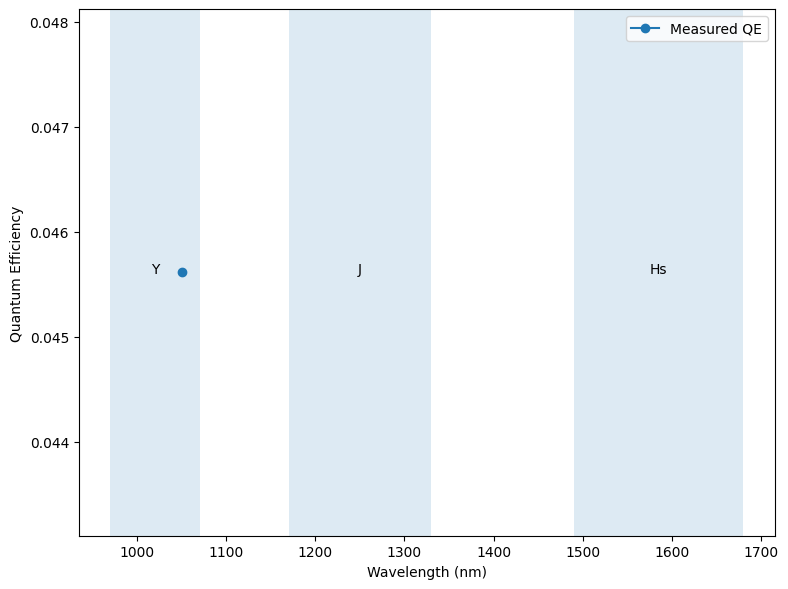

In [64]:
# QE calculation!
print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array([1050])
exp_times = np.array([5])
pd_darks = np.array([0.009]) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.
pd_readings = np.array([1.906]) * 1e-9  # convert nA to A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array([25985.9])  # CCD counts (from histogram peak of diff

meas_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 2.5, thorlabs_pd)
print(meas_qe.qe_vals)



fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_qe.wavelengths, meas_qe.qe_vals, 'o-', label='Measured QE')


print(f"wavelengths: {meas_qe.wavelengths}")
print(f"qe_vals: {meas_qe.qe_vals}")

# overplot the passbands: 
# Define bands: (wl_min, wl_max)
bands = {
    "Y":  (970, 1070),
    "J":  (1170, 1330),
    "Hs": (1490, 1680),
}

# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )

ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)
ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
plt.legend()
plt.tight_layout()
plt.show()


single_point_qe_1050_swir = meas_qe.qe_vals[0]


Single-point QE calculation at 1050 nm
len(wavelengths)=10, len(exp_times)=10, len(pd_darks)=10, len(pd_readings)=10, len(darks)=10, len(readings)=10
[0.04424072 0.00131531 0.00017767 0.00025848 0.00022244 0.00014104
 0.00037703 0.00441849 0.03677878 0.00760362]
wavelengths: [ 400.  500.  550.  600.  640.  700.  800.  900. 1000. 1064.]
qe_vals: [0.04424072 0.00131531 0.00017767 0.00025848 0.00022244 0.00014104
 0.00037703 0.00441849 0.03677878 0.00760362]


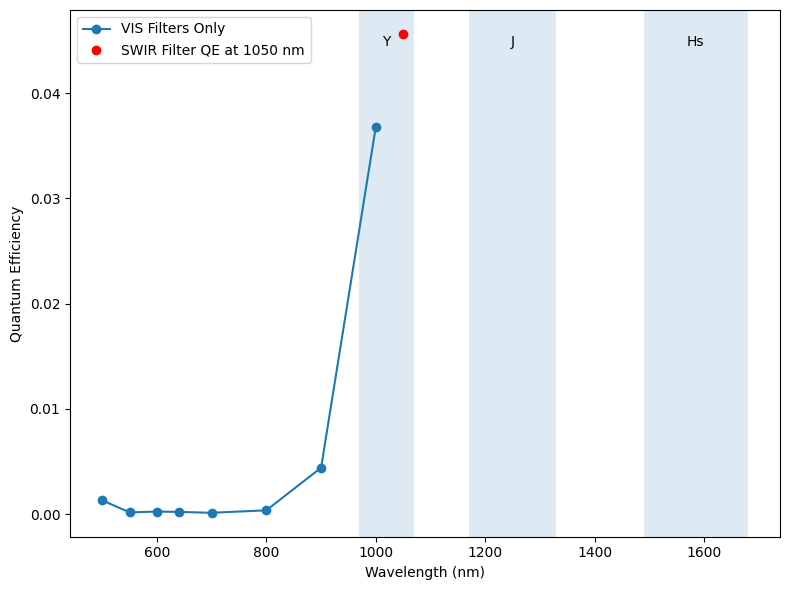

all_wavelengths: [ 500.  550.  600.  640.  700.  800.  900. 1000. 1050.]
all_qe_vals: [0.00131531 0.00017767 0.00025848 0.00022244 0.00014104 0.00037703
 0.00441849 0.03677878 0.04561176]


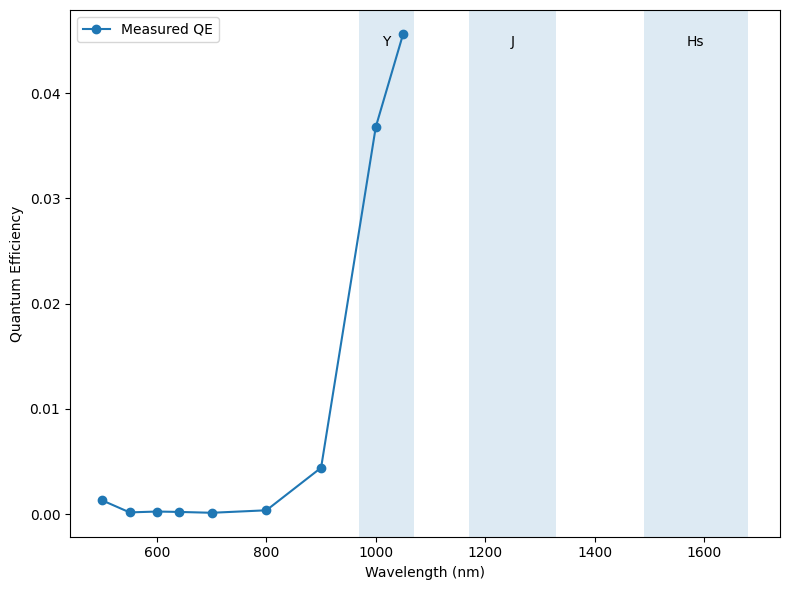

In [68]:
# QE calculation!
print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array([400, 500, 550, 600, 640, 700, 800, 900, 1000, 1064])
exp_times = np.array([30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 2.5, 2.5])
pd_darks = np.zeros_like(wavelengths) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.
pd_readings = np.array([0.004459365999999999, 0.29078038700000003, 0.41176484580000006, 0.4751321019999999, 0.5602558471, 0.5466205289999999, 0.664003598, 2.4884774719999996, 4.678214108, 0.415852588]) * 1e-9  # convert nA to A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array([827.6199951171875, 855.010009765625, 143.6199951171875, 215.85000610351562, 202.85501098632812, 113.47500610351562, 325.30499267578125, 13301.30078125, 17576.1484375, 611.625]
)  # CCD counts (from histogram peak of diff

print(f"len(wavelengths)={len(wavelengths)}, len(exp_times)={len(exp_times)}, len(pd_darks)={len(pd_darks)}, len(pd_readings)={len(pd_readings)}, len(darks)={len(darks)}, len(readings)={len(readings)}")

meas_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 2.5, thorlabs_pd)
print(meas_qe.qe_vals)



fig, ax = plt.subplots(figsize=(8,6))
#ax.plot(meas_qe.wavelengths, meas_qe.qe_vals, 'o-', label='VIS Filters + Shortpass Filter')


print(f"wavelengths: {meas_qe.wavelengths}")
print(f"qe_vals: {meas_qe.qe_vals}")

wavelengths_to_remove = [400, 1064]
mask = ~np.isin(meas_qe.wavelengths, wavelengths_to_remove)
ax.plot(meas_qe.wavelengths[mask], meas_qe.qe_vals[mask], 'o-', label='VIS Filters Only')

# plot the single SWIR point @ 1050 nm
ax.plot(1050, single_point_qe_1050_swir, 'ro', label='SWIR Filter QE at 1050 nm')

# overplot the passbands: 
# Define bands: (wl_min, wl_max)
bands = {
    "Y":  (970, 1070),
    "J":  (1170, 1330),
    "Hs": (1490, 1680),
}

# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )
ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)
ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
plt.legend()
plt.tight_layout()
plt.show()


# combine all the data

all_wavelengths = np.append(meas_qe.wavelengths[mask], 1050)
all_qe_vals = np.append(meas_qe.qe_vals[mask], single_point_qe_1050_swir)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(all_wavelengths, all_qe_vals, 'o-', label='Measured QE')
print(f"all_wavelengths: {all_wavelengths}")
print(f"all_qe_vals: {all_qe_vals}")
# overplot the passbands: 
# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )
ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)
ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
plt.legend()
plt.tight_layout()
plt.show()



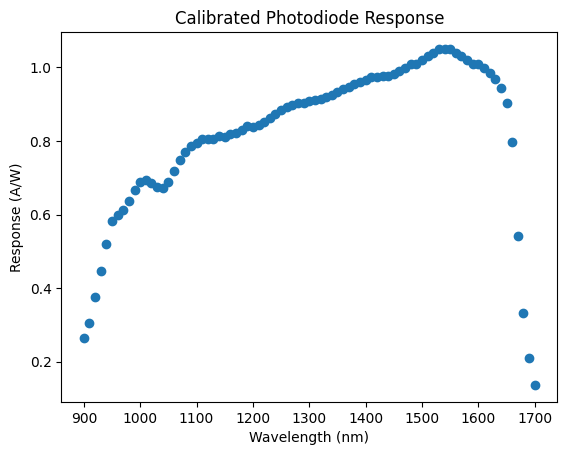


Single-point QE calculation at 1050 nm
lockin amp (V): [0.06237 0.04064 0.00948 0.00456 0.006  ]
convert lockin V --> I with TIA gain of 1e8 V/A
lockin amp (A): [6.237e-10 4.064e-10 9.480e-11 4.560e-11 6.000e-11]
convert lockin peak amplitude --> average delta current with factor of π*sqrt(2)/2
lockin delta I (A): [7.209972e-10 4.697984e-10 1.095888e-10 5.271360e-11 6.936000e-11]
lockin delta I (nA): [0.7209972 0.4697984 0.1095888 0.0527136 0.06936  ]



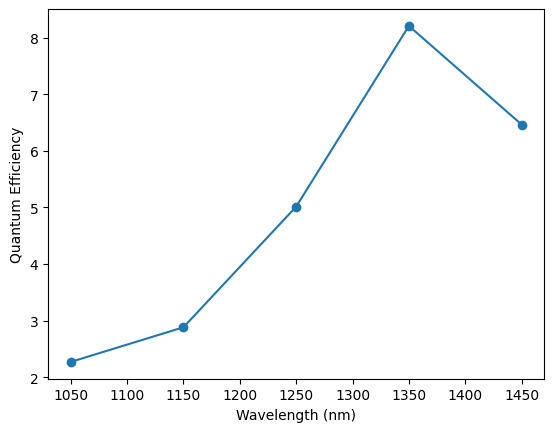


Single-point QE calculation at 1050 nm
len(wavelengths)=10, len(exp_times)=10, len(pd_darks)=10, len(pd_readings)=10, len(darks)=10, len(readings)=10
[0.06912612 0.00205518 0.00027761 0.00040387 0.00034756 0.00022037
 0.0005891  0.0069039  0.05746685 0.01188066]
wavelengths: [ 400.  500.  550.  600.  640.  700.  800.  900. 1000. 1064.]
qe_vals: [0.06912612 0.00205518 0.00027761 0.00040387 0.00034756 0.00022037
 0.0005891  0.0069039  0.05746685 0.01188066]


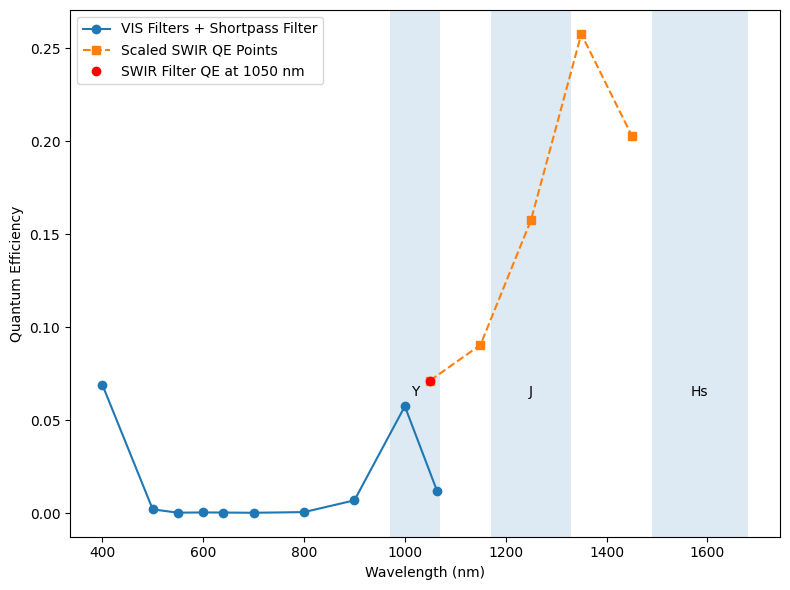

In [53]:
# lockin data in the SWIR: close to the sphere

data_dir = this_dir + '/data/'
ingaas_pd_filename = 'InGaAs_FGA10_PD.csv'
ingaas_pd = CalibratedPD(ingaas_pd_filename, 1, plot=True)


print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array([1050., 1150., 1250., 1350., 1450.])
exp_times = np.array([0.7, 1.0, 2.3, 2.9, 2.7])
pd_darks = np.zeros_like(wavelengths) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.

lockin_amplitude_voltage = np.array([0.06237, 0.04064, 0.00948, 0.00456, 0.006  ])

print(f"lockin amp (V): {lockin_amplitude_voltage}")
print("convert lockin V --> I with TIA gain of 1e8 V/A")
lockin_amplitude_current = lockin_amplitude_voltage / 1e8  # A
print(f"lockin amp (A): {lockin_amplitude_current}")

# scale the reading from fundamental amplitude to average delta current
# for a squre wave, average amplitude = π*sqrt(2)/2 * peak amplitude
print("convert lockin peak amplitude --> average delta current with factor of π*sqrt(2)/2")
#lockin_current_scaling_factor = (np.pi * 2**0.5) / 2
lockin_current_scaling_factor = 1.156
delta_current_avg_A = lockin_amplitude_current* lockin_current_scaling_factor
print(f"lockin delta I (A): {delta_current_avg_A}")
delta_current_avg_nA = delta_current_avg_A * 1e9
print(f"lockin delta I (nA): {delta_current_avg_nA}")
print()


pd_readings = delta_current_avg_A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array([31656.75390625, 34807.75390625, 32429.27539062, 32867.67578125, 32403.48046875])  # counts (from histogram peak of diff


swir_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 1.6, ingaas_pd)

swir_qe.plot_qe()

type(swir_qe.qe_vals)

scaled_swir_qe_vals = swir_qe.qe_vals*0.07126838/swir_qe.qe_vals[0]

###########################################################################
# add the scaled SWIR QE points to the previous QECalc object
###########################################################################
# QE calculation!
print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array([400, 500, 550, 600, 640, 700, 800, 900, 1000, 1064])
exp_times = np.array([30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 2.5, 2.5])
pd_darks = np.zeros_like(wavelengths) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.
pd_readings = np.array([0.004459365999999999, 0.29078038700000003, 0.41176484580000006, 0.4751321019999999, 0.5602558471, 0.5466205289999999, 0.664003598, 2.4884774719999996, 4.678214108, 0.415852588]) * 1e-9  # convert nA to A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array([827.6199951171875, 855.010009765625, 143.6199951171875, 215.85000610351562, 202.85501098632812, 113.47500610351562, 325.30499267578125, 13301.30078125, 17576.1484375, 611.625]
)  # CCD counts (from histogram peak of diff

print(f"len(wavelengths)={len(wavelengths)}, len(exp_times)={len(exp_times)}, len(pd_darks)={len(pd_darks)}, len(pd_readings)={len(pd_readings)}, len(darks)={len(darks)}, len(readings)={len(readings)}")

meas_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 1.6, thorlabs_pd)
print(meas_qe.qe_vals)



fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_qe.wavelengths, meas_qe.qe_vals, 'o-', label='VIS Filters + Shortpass Filter')


print(f"wavelengths: {meas_qe.wavelengths}")
print(f"qe_vals: {meas_qe.qe_vals}")

# overplot the passbands: 
# Define bands: (wl_min, wl_max)
bands = {
    "Y":  (970, 1070),
    "J":  (1170, 1330),
    "Hs": (1490, 1680),
}

# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )



# scaled SWIR qe vals (from below):
ax.plot(swir_qe.wavelengths, scaled_swir_qe_vals, 's--', label='Scaled SWIR QE Points')


# single point at 1050 nm
ax.plot(1050, 0.07126838, 'ro', label='SWIR Filter QE at 1050 nm')

ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
#ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)

plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
meas_filters = [1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0, 1050.0, 1150.0, 1250.0, 1350.0, 1450.0]

meas_exptimes = [0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7, 0.7, 1.0, 2.3, 2.9, 2.7]

count_diff_peaks = [31667.740234375, 34711.0546875, 31924.34375, 32612.91015625, 32352.0703125, 31725.3046875, 34727.73828125, 32441.125, 32631.59375, 31930.5703125, 32180.98046875, 34797.125, 31998.07421875, 32415.16015625, 32355.69921875, 31714.18359375, 34847.8671875, 32406.2265625, 32855.44921875, 31989.30859375, 31779.234375, 34787.37890625, 32451.07421875, 32672.765625, 31937.01171875, 31744.73828125, 34886.7578125, 32399.548828125, 32644.03515625, 32194.94921875, 31526.890625, 34721.7734375, 31905.609375, 32649.21484375, 31931.59375, 31682.62890625, 34721.828125, 31946.4453125, 32705.58984375, 31939.234375, 31774.625, 34808.0, 32411.375, 32588.109375, 32031.33984375, 32208.359375, 34800.11328125, 32048.474609375, 32275.87890625, 32165.5234375]

lockin_amp_diffs = [0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006, 0.06237, 0.04064, 0.00948, 0.00456, 0.006]



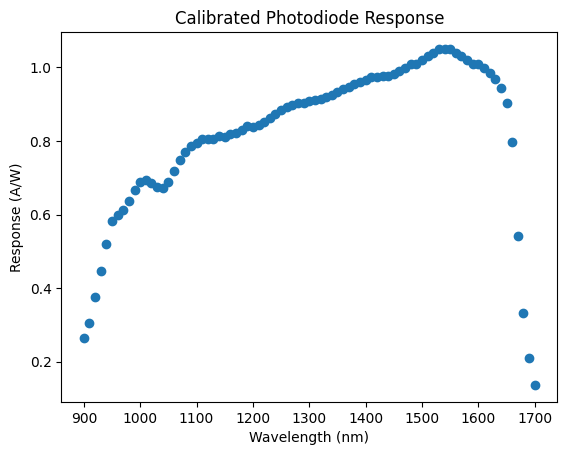


Single-point QE calculation at 1050 nm
lockin amp (V): [0.06237 0.04064 0.00948 0.00456 0.006   0.06237 0.04064 0.00948 0.00456
 0.006   0.06237 0.04064 0.00948 0.00456 0.006   0.06237 0.04064 0.00948
 0.00456 0.006   0.06237 0.04064 0.00948 0.00456 0.006   0.06237 0.04064
 0.00948 0.00456 0.006   0.06237 0.04064 0.00948 0.00456 0.006   0.06237
 0.04064 0.00948 0.00456 0.006   0.06237 0.04064 0.00948 0.00456 0.006
 0.06237 0.04064 0.00948 0.00456 0.006  ]
convert lockin V --> I with TIA gain of 1e8 V/A
lockin amp (A): [6.237e-10 4.064e-10 9.480e-11 4.560e-11 6.000e-11 6.237e-10 4.064e-10
 9.480e-11 4.560e-11 6.000e-11 6.237e-10 4.064e-10 9.480e-11 4.560e-11
 6.000e-11 6.237e-10 4.064e-10 9.480e-11 4.560e-11 6.000e-11 6.237e-10
 4.064e-10 9.480e-11 4.560e-11 6.000e-11 6.237e-10 4.064e-10 9.480e-11
 4.560e-11 6.000e-11 6.237e-10 4.064e-10 9.480e-11 4.560e-11 6.000e-11
 6.237e-10 4.064e-10 9.480e-11 4.560e-11 6.000e-11 6.237e-10 4.064e-10
 9.480e-11 4.560e-11 6.000e-11 6.237e-10 4.064e-1

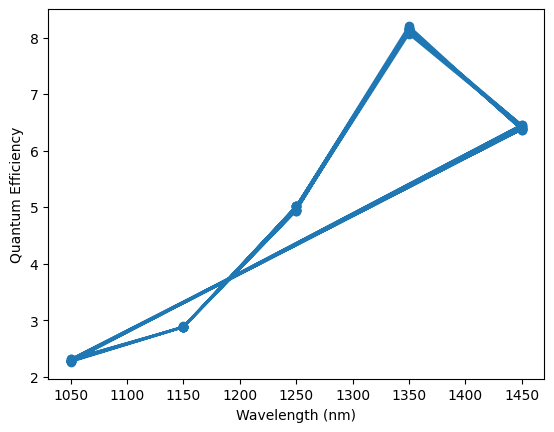


Single-point QE calculation at 1050 nm
len(wavelengths)=10, len(exp_times)=10, len(pd_darks)=10, len(pd_readings)=10, len(darks)=10, len(readings)=10
[0.06912612 0.00205518 0.00027761 0.00040387 0.00034756 0.00022037
 0.0005891  0.0069039  0.05746685 0.01188066]
wavelengths: [ 400.  500.  550.  600.  640.  700.  800.  900. 1000. 1064.]
qe_vals: [0.06912612 0.00205518 0.00027761 0.00040387 0.00034756 0.00022037
 0.0005891  0.0069039  0.05746685 0.01188066]


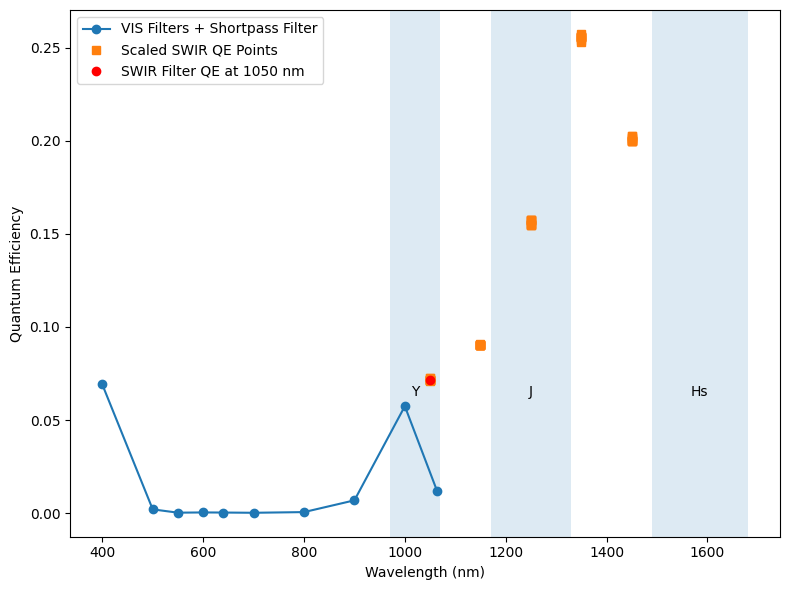

In [56]:
# lockin data in the SWIR: close to the sphere

data_dir = this_dir + '/data/'
ingaas_pd_filename = 'InGaAs_FGA10_PD.csv'
ingaas_pd = CalibratedPD(ingaas_pd_filename, 1, plot=True)


print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array(meas_filters)
exp_times = np.array(meas_exptimes)
pd_darks = np.zeros_like(wavelengths) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.

lockin_amplitude_voltage = np.array(lockin_amp_diffs)
print(f"lockin amp (V): {lockin_amplitude_voltage}")
print("convert lockin V --> I with TIA gain of 1e8 V/A")
lockin_amplitude_current = lockin_amplitude_voltage / 1e8  # A
print(f"lockin amp (A): {lockin_amplitude_current}")

# scale the reading from fundamental amplitude to average delta current
# for a squre wave, average amplitude = π*sqrt(2)/2 * peak amplitude
print("convert lockin peak amplitude --> average delta current with factor of π*sqrt(2)/2")
#lockin_current_scaling_factor = (np.pi * 2**0.5) / 2
lockin_current_scaling_factor = 1.156
delta_current_avg_A = lockin_amplitude_current* lockin_current_scaling_factor
print(f"lockin delta I (A): {delta_current_avg_A}")
delta_current_avg_nA = delta_current_avg_A * 1e9
print(f"lockin delta I (nA): {delta_current_avg_nA}")
print()


pd_readings = delta_current_avg_A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array(count_diff_peaks)  # counts (from histogram peak of diff


swir_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 1.6, ingaas_pd)

swir_qe.plot_qe()

type(swir_qe.qe_vals)

scaled_swir_qe_vals = swir_qe.qe_vals*0.07126838/swir_qe.qe_vals[0]

###########################################################################
# add the scaled SWIR QE points to the previous QECalc object
###########################################################################
# QE calculation!
print("\nSingle-point QE calculation at 1050 nm")
wavelengths = np.array([400, 500, 550, 600, 640, 700, 800, 900, 1000, 1064])
exp_times = np.array([30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 30.0, 2.5, 2.5])
pd_darks = np.zeros_like(wavelengths) * 1e-9 # PD dark current in A (assume zero since we're calculating diff)
# PD reading measured as average of ammeter reading over duration of captured frames.
pd_readings = np.array([0.004459365999999999, 0.29078038700000003, 0.41176484580000006, 0.4751321019999999, 0.5602558471, 0.5466205289999999, 0.664003598, 2.4884774719999996, 4.678214108, 0.415852588]) * 1e-9  # convert nA to A
darks = np.zeros_like(wavelengths)  # CCD dark counts (assume zero since we're calculating diff)
readings = np.array([827.6199951171875, 855.010009765625, 143.6199951171875, 215.85000610351562, 202.85501098632812, 113.47500610351562, 325.30499267578125, 13301.30078125, 17576.1484375, 611.625]
)  # CCD counts (from histogram peak of diff

print(f"len(wavelengths)={len(wavelengths)}, len(exp_times)={len(exp_times)}, len(pd_darks)={len(pd_darks)}, len(pd_readings)={len(pd_readings)}, len(darks)={len(darks)}, len(readings)={len(readings)}")

meas_qe = QECalc(wavelengths, exp_times, pd_darks, pd_readings,
              darks, readings, (15 * 10 ** -4) ** 2, 1.6, thorlabs_pd)
print(meas_qe.qe_vals)



fig, ax = plt.subplots(figsize=(8,6))
ax.plot(meas_qe.wavelengths, meas_qe.qe_vals, 'o-', label='VIS Filters + Shortpass Filter')


print(f"wavelengths: {meas_qe.wavelengths}")
print(f"qe_vals: {meas_qe.qe_vals}")

# overplot the passbands: 
# Define bands: (wl_min, wl_max)
bands = {
    "Y":  (970, 1070),
    "J":  (1170, 1330),
    "Hs": (1490, 1680),
}

# Optionally grab y-limits so spans cover full QE range
ymin, ymax = ax.get_ylim()

for i, (name, (wl_min, wl_max)) in enumerate(bands.items()):
    ax.axvspan(
        wl_min, wl_max,
        ymin=0, ymax=1,           # full height in axis coords
        alpha=0.15,
        #label=name if i == 0 else None,  # avoid duplicate legend entries
    )
    # Optional: label at the center of each band
    x_center = 0.5 * (wl_min + wl_max)
    ax.text(
        x_center, ymax * 0.95,
        name,
        ha="center", va="top",
    )



# scaled SWIR qe vals (from below):
ax.plot(swir_qe.wavelengths, scaled_swir_qe_vals, 's', label='Scaled SWIR QE Points')


# single point at 1050 nm
ax.plot(1050, 0.07126838, 'ro', label='SWIR Filter QE at 1050 nm')

ax.set_ylabel("Quantum Efficiency")
ax.set_xlabel("Wavelength (nm)")
#ax.set_ylim(ymin, ymax)  # restore original y-limits (axvspan can sometimes nudge them)

plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'sen' is not defined